In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from PIL import Image
import cv2
import os

In [2]:
df=pd.read_csv(r'../data/processed/FinalData.csv')

In [3]:
df

,uid,filename,projection,MeSH,Problems,image,indication,comparison,findings,impression,impression_class
0,1,1_IM-0001-4001.dcm.png,Frontal,normal,normal,Xray Chest PA and Lateral,Positive TB test,NaN,The cardiac silhouette and mediastinum size ar...,Normal chest x-,Normal
1,1,1_IM-0001-3001.dcm.png,Lateral,normal,normal,Xray Chest PA and Lateral,Positive TB test,NaN,The cardiac silhouette and mediastinum size ar...,Normal chest x-,Normal
2,2,2_IM-0652-1001.dcm.png,Frontal,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,NaN,Borderline cardiomegaly. Midline sternotomy . ...,No acute pulmonary findings.,Normal
3,2,2_IM-0652-2001.dcm.png,Lateral,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,NaN,Borderline cardiomegaly. Midline sternotomy . ...,No acute pulmonary findings.,Normal
4,3,3_IM-1384-1001.dcm.png,Frontal,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",Unknown,"No displaced rib fractures, pneumothorax, or p...","No displaced rib fractures, pneumothorax, or p...",Normal
...,...,...,...,...,...,...,...,...,...,...,...
7290,3997,3997_IM-2048-1002.dcm.png,Lateral,Opacity/lung/upper lobe/right/round/small;Gran...,Opacity;Granuloma,PA and lateral views of the chest.,XXXX-year-old male with positive PPD.,Noneavailable,"Heart size within normal limits. Small, nodula...","No acute findings, no evidence for active TB.",Normal
7291,3998,3998_IM-2048-1001.dcm.png,Frontal,normal,normal,"PA and lateral chest XXXX, XXXX XXXX comparis...",tuberculosis positive PPD,Unknown,Heart size is normal and the lungs are clear.,Heart size is normal and the lungs are clear.,Normal
7292,3998,3998_IM-2048-1002.dcm.png,Lateral,normal,normal,"PA and lateral chest XXXX, XXXX XXXX comparis...",tuberculosis positive PPD,Unknown,Heart size is normal and the lungs are clear.,Heart size is normal and the lungs are clear.,Normal
7293,3999,3999_IM-2049-1001.dcm.png,Frontal,normal,normal,"CHEST PA and LATERAL: on XXXX, XXXX.",This is a XXXX-year-old female patient with sh...,"Chest x-None, None,",The cardiac silhouette is normal in size and c...,The cardiac silhouette is normal in size and c...,Normal


<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\mohma\AppData\Local\Temp\ipykernel_20628\162228809.py:2: SyntaxWarning: invalid escape sequence '\d'
  folder_path="..\data\processed\images"


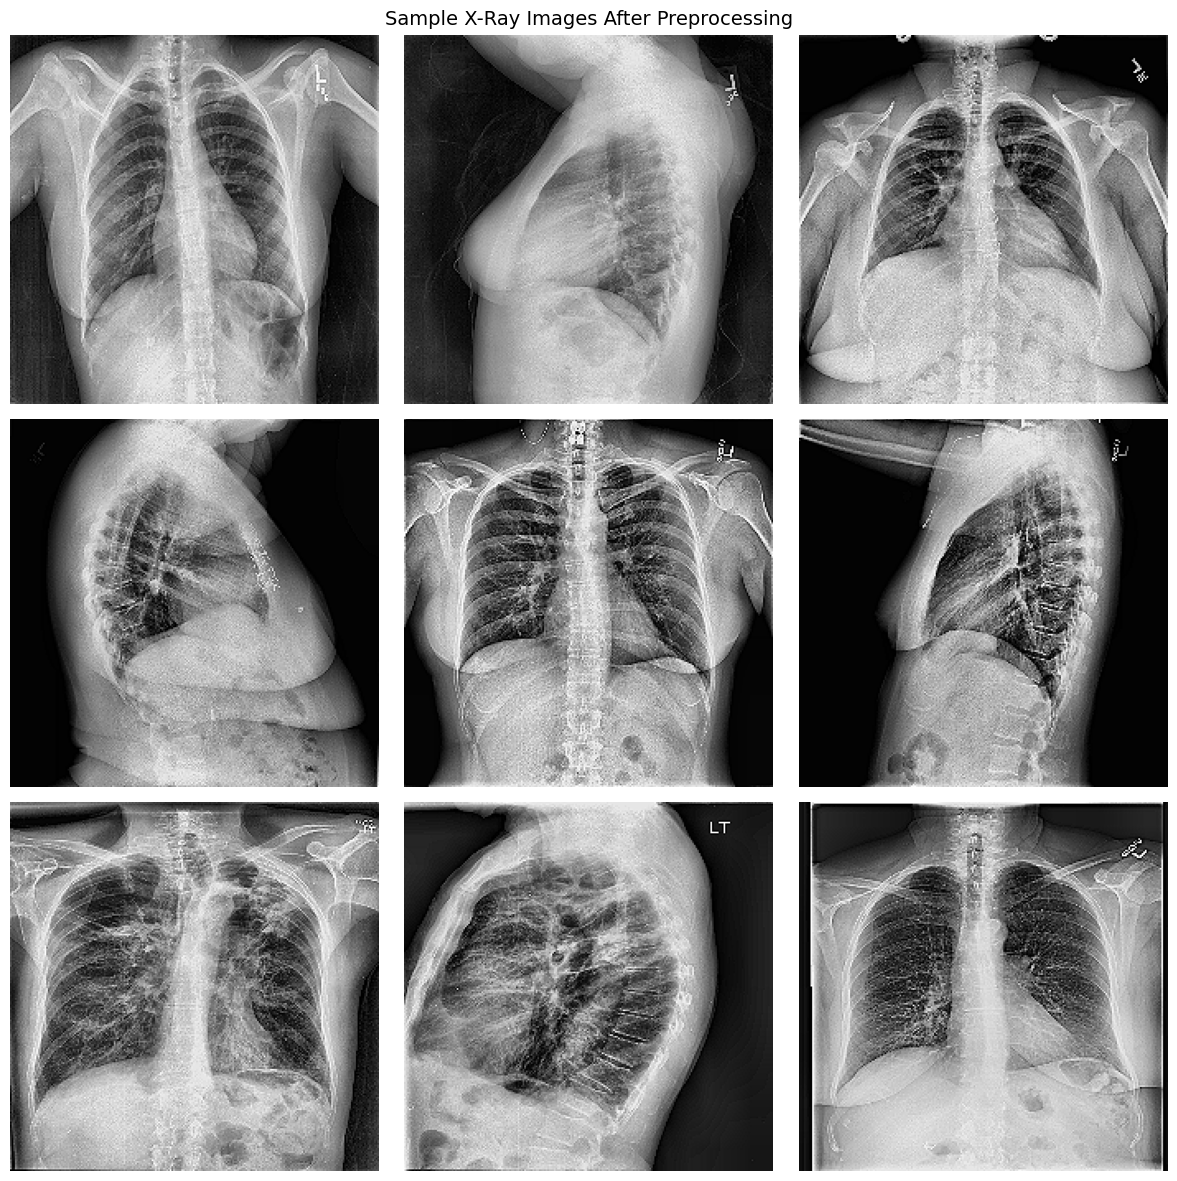

In [4]:
# ✅ عرض أول 9 صور
folder_path="..\data\processed\images"
image_path=df["filename"].apply(lambda x:(os.path.join(folder_path,x))).values
plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i+1)
    img=cv2.imread(image_path[i])
    plt.imshow(img)
    plt.axis("off")

plt.suptitle("Sample X-Ray Images After Preprocessing", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
df["impression_class"].value_counts()

impression_class
Normal                  5025
Other                   1279
Pneumonia/Infiltrate     363
Cardiomegaly             211
Pleural Effusion         148
Pneumothorax             124
Atelectasis              106
Fibrosis/Scarring         39
Name: count, dtype: int64

In [6]:
IMG_SIZE    = (224, 224)
def load_image(filename):
    """قراءة الصورة وتحويلها لـ grayscale"""
    path = os.path.join(folder_path, filename)
    try:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return None
        img = cv2.resize(img, IMG_SIZE)
        img = img / 255.0
        return img
    except Exception as e:
        print(f"❌ Error loading {filename}: {e}")
        return None
    
print("Reading images... (this may take a moment)")
df['image'] = df['filename'].apply(load_image)

Reading images... (this may take a moment)


In [7]:
valid_mask = df['image'].notna()
df = df[valid_mask].reset_index(drop=True)

In [8]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['impression_class'])
num_classes = df['impression_class'].nunique()
print(f"✅ Total classes: {num_classes}")

✅ Total classes: 8


In [9]:
import tensorflow.keras as keras
import tensorflow as tf
from tensorflow.keras import layers

In [10]:
X = np.array([img.reshape(IMG_SIZE[0], IMG_SIZE[1], 1) for img in df['image']])
y_one_hot = keras.utils.to_categorical(y, num_classes)

In [11]:
from sklearn.model_selection import train_test_split
X_train,x_temp,y_train,y_temp=train_test_split(X,y_one_hot,test_size=0.3,random_state=42,stratify=y)
X_val,X_test,y_val,y_test=train_test_split(x_temp,y_temp,test_size=0.5,random_state=42,stratify=np.argmax(y_temp, axis=1))

In [13]:
BATCH_SIZE  = 32
NUM_CLASSES = df["impression_class"].value_counts().shape[0] # 8
AUTOTUNE = tf.data.AUTOTUNE
# Data Augmentation طبقة جوه الموديل نفسه
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),      
    layers.RandomRotation(0.1),           
    layers.RandomZoom(0.1),               
    layers.RandomContrast(0.1), 
    layers.GaussianNoise(0.02)          
], name='data_augmentation')

# تحميل الداتا من المجلدات
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(buffer_size=1000)
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x), y),
    num_parallel_calls=AUTOTUNE
)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
print(f"✅ Train batches: {len(train_ds)}")
print(f"✅ Val batches: {len(val_ds)}")
print(f"✅ Test batches: {len(test_ds)}")

✅ Train batches: 160
✅ Val batches: 35
✅ Test batches: 35


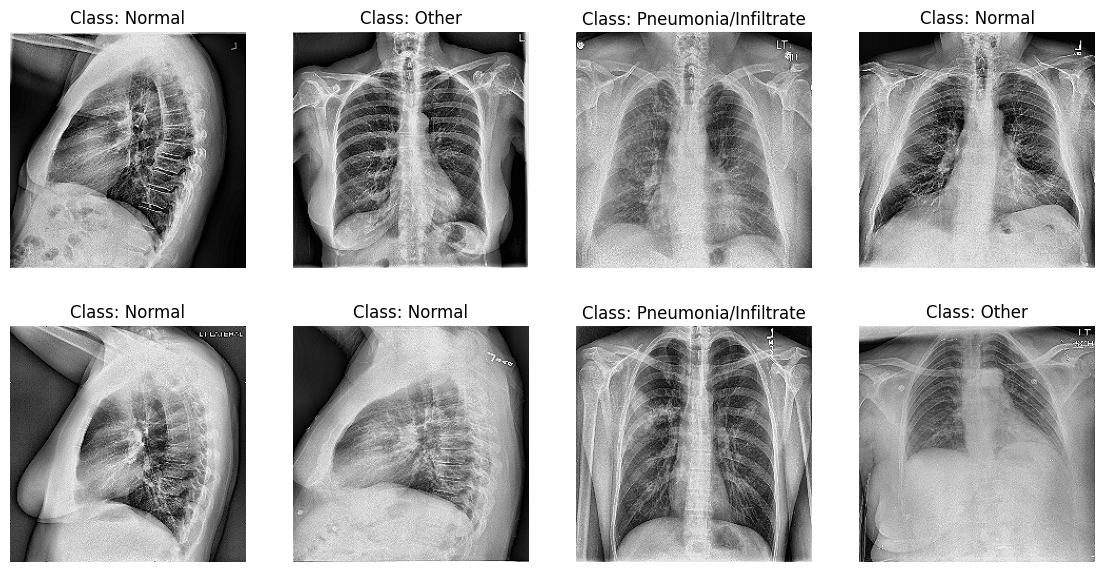

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    if i < len(X_train):
        ax.imshow(X_train[i].reshape(IMG_SIZE), cmap='gray')
        class_name = le.classes_[np.argmax(y_train[i])]
        ax.set_title(f"Class: {class_name}")
        ax.axis('off')

In [15]:
print("="*70)
print("💾 SAVING PROCESSED IMAGES")
print("="*70)


output_dir = r'../data/processed/train_val_test'
os.makedirs(output_dir, exist_ok=True)

# حفظ Train
np.save(os.path.join(output_dir, 'X_train.npy'), X_train)
np.save(os.path.join(output_dir, 'y_train.npy'), y_train)

# حفظ Val
np.save(os.path.join(output_dir, 'X_val.npy'), X_val)
np.save(os.path.join(output_dir, 'y_val.npy'), y_val)

# حفظ Test
np.save(os.path.join(output_dir, 'X_test.npy'), X_test)
np.save(os.path.join(output_dir, 'y_test.npy'), y_test)

# حفظ LabelEncoder
import pickle
with open(os.path.join(output_dir, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(le, f)

print(f"✅ X_train.npy: {X_train.shape}")
print(f"✅ X_val.npy: {X_val.shape}")
print(f"✅ X_test.npy: {X_test.shape}")
print(f"✅ LabelEncoder saved")
print(f"\n✅ All data saved to: {output_dir}")

💾 SAVING PROCESSED IMAGES
✅ X_train.npy: (5106, 224, 224, 1)
✅ X_val.npy: (1094, 224, 224, 1)
✅ X_test.npy: (1095, 224, 224, 1)
✅ LabelEncoder saved

✅ All data saved to: ../data/processed/train_val_test
